<a href="https://colab.research.google.com/github/PrathyushaMyla2005/google-colab/blob/main/Vast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [324]:
import pandas as pd
import numpy as np
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

In [325]:
data = pd.read_csv("/content/VAST_test.csv")
data = pd.read_csv("/content/VAST_train_11k.csv")
data = pd.read_csv("/content/VAST_val.csv")
print(data.head())
print("Dataset shape:", data.shape)

                                               Tweet         Target 1  \
0  The comments can "improve the quality of work ...  comment section   
1  Is there zero personal accountability in today...          obesity   
2  Is there zero personal accountability in today...  personal health   
3  Is there zero personal accountability in today...      weight gain   
4  Look, there are issues to be debateed. Do we n...          library   

  Stance 1  seen?  
0  AGAINST      1  
1  AGAINST      1  
2    FAVOR      0  
3  AGAINST      0  
4  AGAINST      1  
Dataset shape: (2062, 4)


In [326]:
data.columns = data.columns.str.strip()

print("Columns:", data.columns)

Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')


In [327]:
data['input_text'] = data['Tweet'] + " target " + data['Target 1']

print(data[['input_text']].head())

                                          input_text
0  The comments can "improve the quality of work ...
1  Is there zero personal accountability in today...
2  Is there zero personal accountability in today...
3  Is there zero personal accountability in today...
4  Look, there are issues to be debateed. Do we n...


In [328]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [329]:
print(data.columns)

Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')


In [330]:
encoder = LabelEncoder()

data['label'] = encoder.fit_transform(data['Stance 1'])

print(data[['Stance 1','label']].head())

  Stance 1  label
0  AGAINST      0
1  AGAINST      0
2    FAVOR      1
3  AGAINST      0
4  AGAINST      0


In [331]:
tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(data['input_text'])

sequences = tokenizer.texts_to_sequences(data['input_text'])

In [332]:
print(sequences[0])

[1, 77, 36, 1035, 1, 630, 5, 94, 17, 704, 250, 38, 52, 22, 581, 24, 15, 1608, 6467, 26, 51, 7811, 9, 118, 221, 1001, 20, 151, 3964, 77, 41, 7, 4, 7812, 148, 9, 3965, 2, 92, 486, 5, 1609, 308, 3966, 155, 69, 309, 630, 21, 1807, 77, 1205, 191, 119, 630, 2510, 1002, 1, 308, 644, 752, 2, 692, 1, 630, 5, 22, 92, 122, 1, 349, 7, 49, 5, 1, 176, 9, 7813, 85, 11, 1, 1206, 5, 92, 486, 7814, 102, 1, 4724, 5, 7815, 3428, 12, 92, 122]


In [333]:
max_len = 100

X = pad_sequences(sequences, maxlen=max_len)

In [334]:
y = data['label']

In [335]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1649, 100)
Testing samples: (413, 100)


In [336]:
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("Max sequence length:", max_len)

Vocabulary size: 8733
Max sequence length: 100


load glove

In [14]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-13 10:25:10--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-13 10:25:11--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-13 10:25:11--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [15]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [16]:
import numpy as np

embedding_dim = 100
embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:

    for line in f:

        values = line.split()

        word = values[0]

        vector = np.asarray(values[1:], dtype='float32')

        embeddings_index[word] = vector

print("Total words in GloVe:", len(embeddings_index))

Total words in GloVe: 400000


In [17]:
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():

    vector = embeddings_index.get(word)

    if vector is not None:

        embedding_matrix[i] = vector

In [70]:
input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

lstm_layer = LSTM(128)(embedding_layer)

dropout_layer = Dropout(0.3)(lstm_layer)

output_layer = Dense(3, activation='softmax')(dropout_layer)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 100)       │       873,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 990,935 (3.78 MB)

 Trainable params: 117,635 (459.51 KB)

 Non-trainable params: 873,300 (3.33 MB)

In [72]:
from sklearn.base import validate_data
import time

start_train = time.time()
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1 # Corrected from validate_data
)

end_train = time.time()

train_time = end_train - start_train

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3726 - loss: 1.1032 - val_accuracy: 0.4424 - val_loss: 1.0827
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4569 - loss: 1.0510 - val_accuracy: 0.4303 - val_loss: 1.0549
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4670 - loss: 1.0283 - val_accuracy: 0.4061 - val_loss: 1.0568
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4899 - loss: 1.0056 - val_accuracy: 0.4061 - val_loss: 1.0696
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5195 - loss: 0.9890 - val_accuracy: 0.3818 - val_loss: 1.0762
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5195 - loss: 0.9742 - val_accuracy: 0.3939 - val_loss: 1.1075
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5236 - loss: 0.9600 - val_accuracy: 0.4424 - val_loss: 1.0752
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5761 - loss: 0.9050 - val_accuracy: 0.4364 - val_l

In [82]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [83]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [84]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 990935
Parameters (Millions): 0.990935


In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [87]:
params = model.count_params()

params_m = params / 1e6

In [81]:
results = [] # Re-initialize the results list
results.append({
    "Model": "LSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [85]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

          Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  LSTM (GloVe)  0.423729   0.419799  0.429581  0.419167         8.080512   

   Inference Time(sec)  Parameters(M)  
0             0.319089       0.990935  


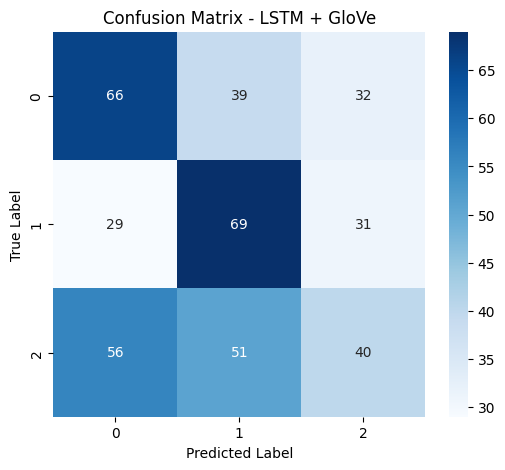

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

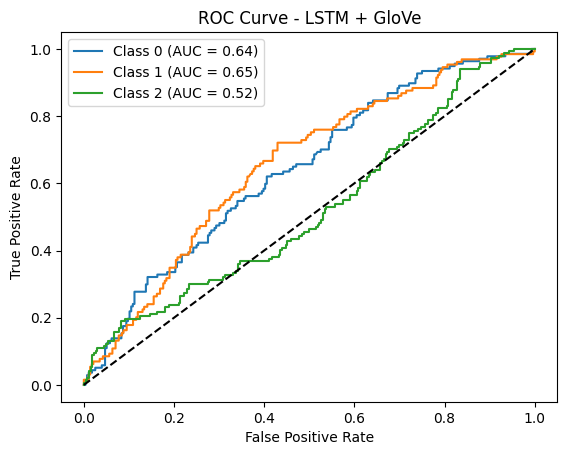

In [89]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + GloVe")

plt.legend()
plt.show()

Attention


In [97]:
import time
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input Layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding Layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
)(input_layer)

# LSTM Layer
lstm_layer = LSTM(64, return_sequences=True)(embedding_layer)

# Attention Layer
attention = Attention()([lstm_layer, lstm_layer])

# Pooling
pooling = GlobalMaxPooling1D()(attention)

# Dropout
drop = Dropout(0.5)(pooling)

# Output Layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

# Compile
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Model Summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 100, 100)  │    873,300 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 100, 64)   │     42,240 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 100, 64)   │          0 │ lstm_4[0][0],     │
│ (Attention)         │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ attention_2[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 3)         │        195 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 915,735 (3.49 MB)

 Trainable params: 915,735 (3.49 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
from tensorflow.keras.callbacks import EarlyStopping
import time
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)
start_train = time.time()
model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)
end_train = time.time()

train_time = end_train - start_train

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3542 - loss: 1.1105 - val_accuracy: 0.3051 - val_loss: 1.1054
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3875 - loss: 1.0872 - val_accuracy: 0.3826 - val_loss: 1.0878
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4033 - loss: 1.0668 - val_accuracy: 0.3220 - val_loss: 1.1450
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4554 - loss: 1.0353 - val_accuracy: 0.3874 - val_loss: 1.1012


In [93]:
start_inf = time.time()
pred = model.predict(X_test)
end_inf = time.time()
inference_time = end_inf - start_inf

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Total Parameters: 990935
Parameters (Millions): 0.990935


In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

params_m = params / 1e6

In [100]:
results.append({
    "Model": "LSTM (Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [103]:
# Remove the GloVe model entry and the older Attention model entry
del results[0]  # Removes the LSTM (GloVe) entry
del results[0]  # Removes the older LSTM (Attention) entry (which was at index 1 before the first deletion)

# Recreate and print the DataFrame with only the latest Attention model result
results_df = pd.DataFrame(results)
print(results_df)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  LSTM (Attention)  0.368039   0.373279  0.367877  0.369538         5.551823   

   Inference Time(sec)  Parameters(M)  
0             0.308441       0.990935  


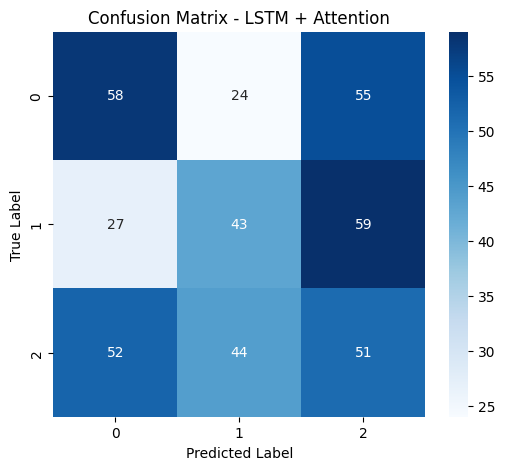

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + Attention")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

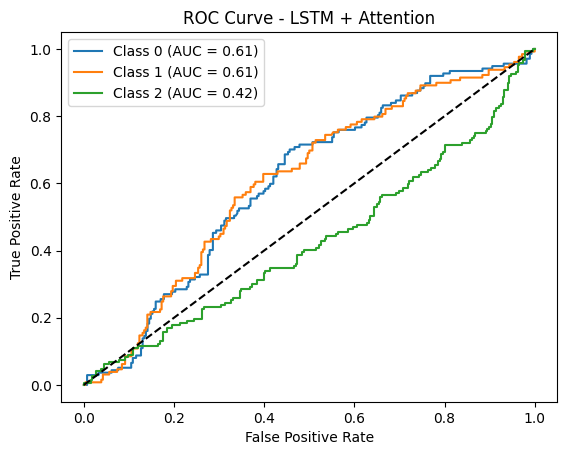

In [105]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + Attention")

plt.legend()
plt.show()

minlstm+glove

In [117]:
import time
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# MINI LSTM (smaller units)
lstm_layer = LSTM(32)(embedding_layer)

# Dropout
dropout_layer = Dropout(0.5)(lstm_layer)

# Output layer
output_layer = Dense(3, activation='softmax')(dropout_layer)

# Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 100, 100)       │       873,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,423 (3.40 MB)

 Trainable params: 17,123 (66.89 KB)

 Non-trainable params: 873,300 (3.33 MB)

In [118]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [119]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3578 - loss: 1.1118 - val_accuracy: 0.3777 - val_loss: 1.0880
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4245 - loss: 1.0639 - val_accuracy: 0.3801 - val_loss: 1.0745
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4536 - loss: 1.0450 - val_accuracy: 0.3898 - val_loss: 1.0735
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4651 - loss: 1.0377 - val_accuracy: 0.3850 - val_loss: 1.0669
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4870 - loss: 1.0255 - val_accuracy: 0.3874 - val_loss: 1.0713
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4991 - loss: 1.0083 - val_accuracy: 0.4092 - val_loss: 1.0630
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4845 - loss: 1.0064 - val_accuracy: 0.3801 - val_loss: 1.0630
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4961 - loss: 0.9974 - val_accuracy: 0.3801 - v

In [120]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [121]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [122]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 890423
Parameters (Millions): 0.890423


In [123]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [124]:
results.append({
    "Model": "Mini LSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [125]:
del results[0]  # Removes the older LSTM (Attention) entry (which was at index 1 before the first deletion)

# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

               Model  Accuracy  Precision   Recall  F1 score  Train Time(sec)  \
0  Mini LSTM (GloVe)  0.375303   0.339392  0.38827  0.345828        34.415961   

   Inference Time(sec)  Parameters(M)  
0             0.300851       0.890423  


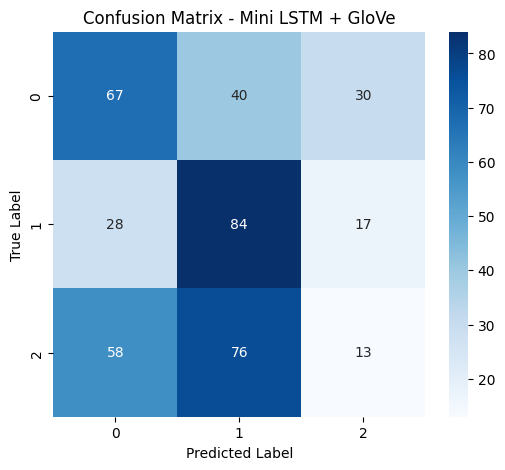

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

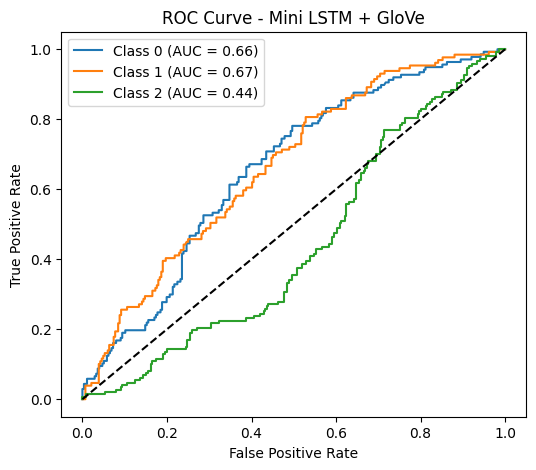

In [116]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + GloVe")

plt.legend()
plt.show()

minlstm+attention

In [158]:
import time
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini LSTM
lstm_layer = LSTM(32, return_sequences=True)(embedding_layer)

# Attention
attention = Attention()([lstm_layer, lstm_layer])

# Pooling
pool = GlobalMaxPooling1D()(attention)

# Dropout
drop = Dropout(0.5)(pool)

# Output
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 100, 100)  │    873,300 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 100, 32)   │     17,024 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_7         │ (None, 100, 32)   │          0 │ lstm_11[0][0],    │
│ (Attention)         │                   │            │ lstm_11[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ attention_7[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ global_max_pooli… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 3)         │         99 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 890,423 (3.40 MB)

 Trainable params: 17,123 (66.89 KB)

 Non-trainable params: 873,300 (3.33 MB)

In [214]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 311ms/step - accuracy: 0.4469 - loss: 1.0405 - val_accuracy: 0.3898 - val_loss: 1.0810
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 382ms/step - accuracy: 0.4645 - loss: 1.0289 - val_accuracy: 0.3777 - val_loss: 1.0789
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 420ms/step - accuracy: 0.4760 - loss: 1.0137 - val_accuracy: 0.3608 - val_loss: 1.0829
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 315ms/step - accuracy: 0.4754 - loss: 1.0128 - val_accuracy: 0.3656 - val_loss: 1.0854
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 306ms/step - accuracy: 0.4888 - loss: 1.0044 - val_accuracy: 0.3438 - val_loss: 1.0881
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 321ms/step - accuracy: 0.4918 - loss: 0.9979 - val_accuracy: 0.3438 - val_loss: 1.0919
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 316ms/step - accuracy: 0.4936 - loss: 0.9904 - val_accuracy: 0.3559 - val_loss: 1.0906
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 307ms/step - accuracy: 0.5039 - loss: 0.9965 - val_accu

In [221]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


In [223]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [224]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 962007
Parameters (Millions): 0.962007


In [225]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [226]:
results.append({
    "Model": "Mini LSTM (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [234]:
results_df = pd.DataFrame(results)
print(results_df[results_df['Model'] == 'Mini LSTM (GloVe + Attention)'])


                           Model  Accuracy  Precision    Recall  F1 score  \
0  Mini LSTM (GloVe + Attention)  0.375303   0.362773  0.380959  0.365658   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
0       1354.50971              0.95505       0.962007  


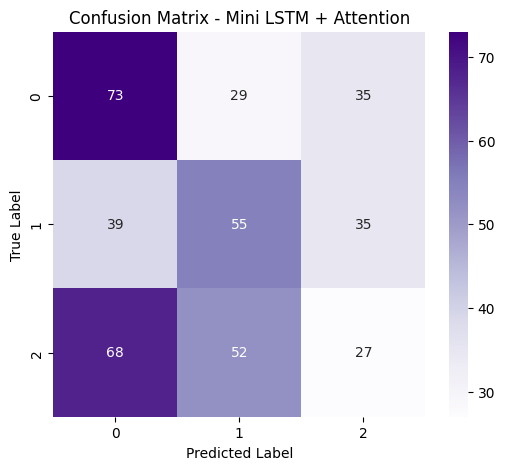

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("Confusion Matrix - Mini LSTM + Attention")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

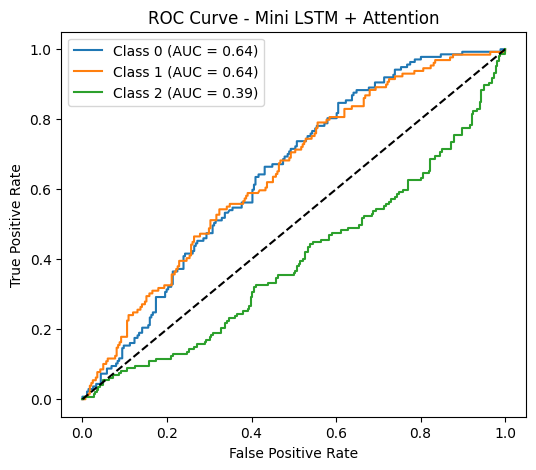

In [228]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + Attention")

plt.legend()
plt.show()

gru+glove

In [179]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# GRU layer
gru_layer = GRU(128, dropout=0.3, recurrent_dropout=0.3)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_13 (Embedding)        │ (None, 100, 100)       │       873,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 962,007 (3.67 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 873,300 (3.33 MB)

In [180]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [200]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.4463 - loss: 1.0372 - val_accuracy: 0.3680 - val_loss: 1.1182
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 310ms/step - accuracy: 0.4645 - loss: 1.0275 - val_accuracy: 0.3971 - val_loss: 1.0832


In [192]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


In [193]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [194]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 962007
Parameters (Millions): 0.962007


In [195]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [201]:
results.append({
    "Model": "GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [236]:
results_df = pd.DataFrame(results)
print(results_df[results_df['Model'] == 'Gru (GloVe)'])


Empty DataFrame
Columns: [Model, Accuracy, Precision, Recall, F1 score, Train Time(sec), Inference Time(sec), Parameters(M)]
Index: []


In [237]:
results_df = pd.DataFrame(results)
print(results_df[results_df['Model'] == 'GRU (GloVe)'])


         Model  Accuracy  Precision   Recall  F1 score  Train Time(sec)  \
1  GRU (GloVe)  0.394673   0.357358  0.40627  0.351787       513.061835   

   Inference Time(sec)  Parameters(M)  
1             0.853669       0.962007  


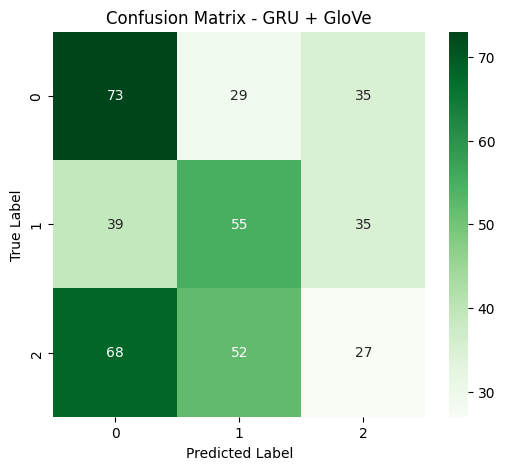

In [238]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - GRU + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

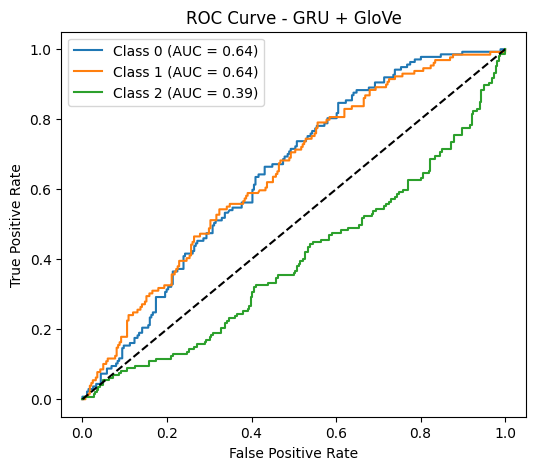

In [239]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU + GloVe")

plt.legend()
plt.show()

gru+attention

In [249]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)(input_layer)

gru_layer = GRU(128, return_sequences=True)(embedding_layer)

attention = Attention()([gru_layer, gru_layer])

pool = GlobalMaxPooling1D()(attention)

drop = Dropout(0.3)(pool)

output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 100, 100)  │    873,300 │ input_layer_16[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 100, 128)  │     88,320 │ embedding_16[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_10        │ (None, 100, 128)  │          0 │ gru_4[0][0],      │
│ (Attention)         │                   │            │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ attention_10[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ global_max_pooli… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 3)         │        387 │ dropout_16[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 962,007 (3.67 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 873,300 (3.33 MB)

In [250]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3523 - loss: 1.1247 - val_accuracy: 0.3632 - val_loss: 1.1012
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3948 - loss: 1.0870 - val_accuracy: 0.3608 - val_loss: 1.1143
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4391 - loss: 1.0543 - val_accuracy: 0.3656 - val_loss: 1.1022
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4845 - loss: 1.0183 - val_accuracy: 0.3826 - val_loss: 1.1014
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5221 - loss: 0.9795 - val_accuracy: 0.3680 - val_loss: 1.1563
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5185 - loss: 0.9626 - val_accuracy: 0.4165 - val_loss: 1.1163
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5731 - loss: 0.9094 - val_accuracy: 0.4165 - val_loss: 1.1328
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6052 - loss: 0.8704 - val_accuracy: 0.3923 - v

In [242]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [251]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 962007
Parameters (Millions): 0.962007


In [252]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [253]:
results.append({
    "Model": "GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [261]:
results_df = pd.DataFrame(results)
cleaned_gru_attention = results_df[results_df['Model'] == 'GRU (GloVe + Attention)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_gru_attention)

                     Model  Accuracy  Precision    Recall  F1 score  \
3  GRU (GloVe + Attention)  0.472155    0.47915  0.472913  0.472292   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
3        13.551381             0.817971       0.962007  


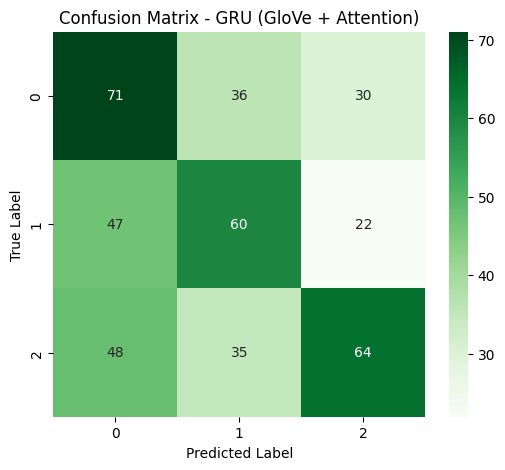

In [262]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

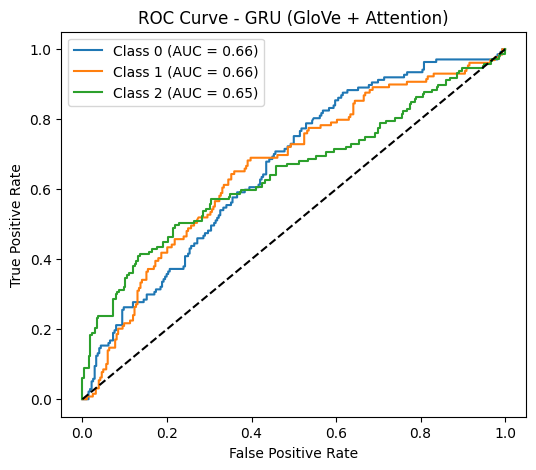

In [263]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU (GloVe + Attention)")

plt.legend()
plt.show()

mingru+glove

In [272]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_18 (Embedding)        │ (None, 100, 100)       │       873,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 32)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 886,263 (3.38 MB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 873,300 (3.33 MB)

In [265]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3535 - loss: 1.1466 - val_accuracy: 0.3898 - val_loss: 1.0893
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3954 - loss: 1.0860 - val_accuracy: 0.3898 - val_loss: 1.0771
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4439 - loss: 1.0573 - val_accuracy: 0.3729 - val_loss: 1.0768
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4488 - loss: 1.0395 - val_accuracy: 0.3898 - val_loss: 1.0750
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4639 - loss: 1.0257 - val_accuracy: 0.3535 - val_loss: 1.0723
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4718 - loss: 1.0127 - val_accuracy: 0.3753 - val_loss: 1.0756
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4736 - loss: 1.0016 - val_accuracy: 0.3874 - val_loss: 1.0859
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4809 - loss: 1.0019 - val_accuracy: 0.3559 - v

In [266]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [267]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [268]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 886263
Parameters (Millions): 0.886263


In [269]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [270]:
results.append({
    "Model": "Mini GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [273]:
results_df = pd.DataFrame(results)
cleaned_mini_gru_glove = results_df[results_df['Model'] == 'Mini GRU (GloVe)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_mini_gru_glove)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
4  Mini GRU (GloVe)  0.363196   0.351816  0.370921  0.356375        22.078225   

   Inference Time(sec)  Parameters(M)  
4             0.292629       0.886263  


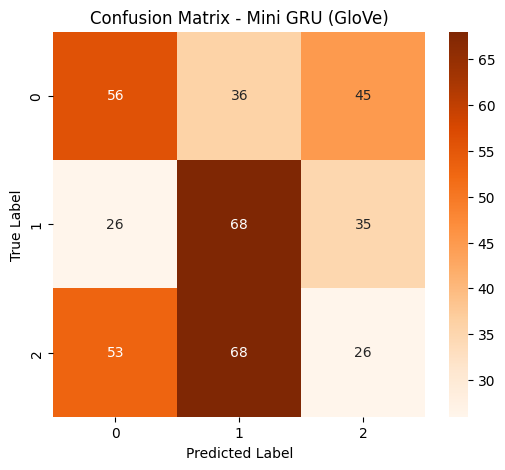

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')

plt.title("Confusion Matrix - Mini GRU (GloVe)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

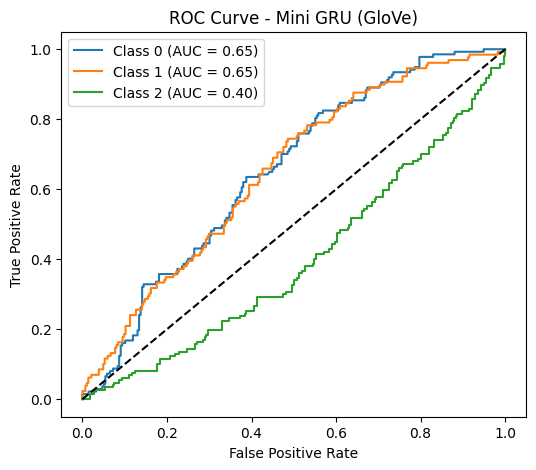

In [275]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe)")

plt.legend()
plt.show()

mingru +attention

In [276]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32, return_sequences=True)(embedding_layer)

# Attention
attention = Attention()([gru_layer, gru_layer])

# Pooling
pool = GlobalMaxPooling1D()(attention)

# Dropout
drop = Dropout(0.3)(pool)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_19        │ (None, 100, 100)  │    873,300 │ input_layer_19[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ (None, 100, 32)   │     12,864 │ embedding_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_11        │ (None, 100, 32)   │          0 │ gru_7[0][0],      │
│ (Attention)         │                   │            │ gru_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ attention_11[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 32)        │          0 │ global_max_pooli… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 3)         │         99 │ dropout_19[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 886,263 (3.38 MB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 873,300 (3.33 MB)

In [277]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3438 - loss: 1.1315 - val_accuracy: 0.3608 - val_loss: 1.0951
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3723 - loss: 1.1009 - val_accuracy: 0.3584 - val_loss: 1.0920
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3699 - loss: 1.0938 - val_accuracy: 0.3341 - val_loss: 1.1016
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4106 - loss: 1.0755 - val_accuracy: 0.3608 - val_loss: 1.0899
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4378 - loss: 1.0585 - val_accuracy: 0.3680 - val_loss: 1.1112
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4579 - loss: 1.0450 - val_accuracy: 0.3777 - val_loss: 1.0943
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4639 - loss: 1.0284 - val_accuracy: 0.3874 - val_loss: 1.0974
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4888 - loss: 1.0120 - val_accuracy: 0.3898 - v

In [278]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [279]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [280]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 886263
Parameters (Millions): 0.886263


In [281]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [282]:
results.append({
    "Model": "Mini GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [285]:
results_df = pd.DataFrame(results)
print(results_df[results_df['Model'] == 'Mini GRU (GloVe + Attention)'])

                          Model  Accuracy  Precision    Recall  F1 score  \
4  Mini GRU (GloVe + Attention)  0.397094   0.380061  0.411312  0.342185   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
4        21.809942             0.707933       0.886263  


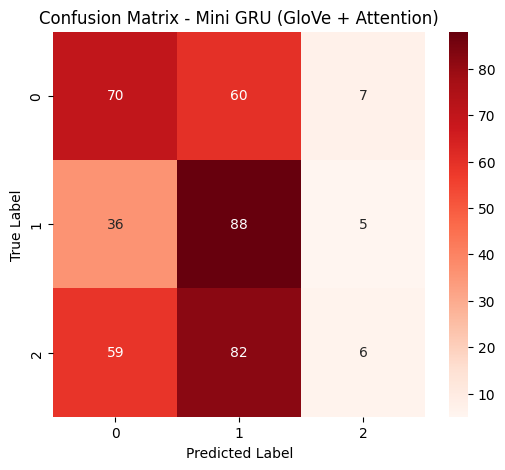

In [286]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title("Confusion Matrix - Mini GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

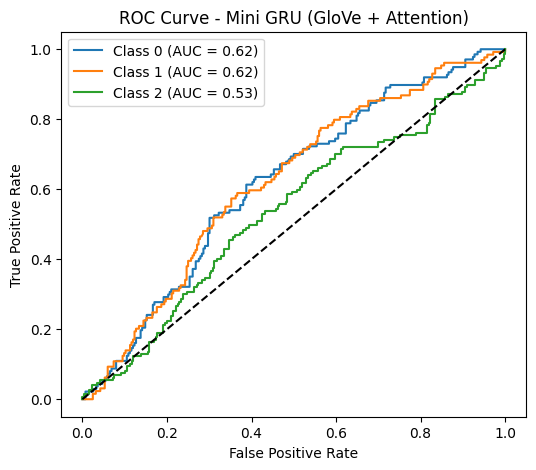

In [287]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe + Attention)")

plt.legend()
plt.show()